In [ ]:
import requests
import pandas as pd


In [ ]:
def fetch_adr_data(drug_name, limit=100):
    base_url = "https://api.fda.gov/drug/event.json"
    params = {
        "search": f"patient.drug.medicinalproduct:{drug_name}",
        "limit": limit
    }
    try:
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.HTTPError as e:
        print(f"Error: {e}")
        return None
        #

In [ ]:
data = fetch_adr_data("PIOGLITAZONE")
print(data['meta']['results']['total'])

14634


In [ ]:
def clean_drug_name(drug):
    return str(drug).strip().upper()
    clean_drug_name("PIOGLITAZONE")

In [ ]:
import re

def clean_drug_name(drug):
    drug = str(drug).lower().strip()

    # remove special characters
    drug = re.sub(r'[^a-z0-9\s]', '', drug)

    # collapse extra spaces
    drug = ' '.join(drug.split())

    return drug

    print(clean_drug_name("PIOGLITAZONE 500mg"))


In [ ]:
import re

def clean_drug_name(drug):
    drug = str(drug).lower().strip()

    # remove special characters
    drug = re.sub(r'[^a-z0-9\s]', '', drug)

    # collapse extra spaces
    drug = ' '.join(drug.split())

    return drug

print(clean_drug_name("PIOGLITAZONE 500mg"))

pioglitazone 500mg


In [ ]:
print(len(data['results']))  # confirms you have 100
print(data['results'][0])    # prints the first report in full

100
{'safetyreportversion': '2', 'safetyreportid': '10005174', 'primarysourcecountry': 'US', 'occurcountry': 'US', 'transmissiondateformat': '102', 'transmissiondate': '20200122', 'reporttype': '1', 'serious': '1', 'seriousnessother': '1', 'receivedateformat': '102', 'receivedate': '20140312', 'receiptdateformat': '102', 'receiptdate': '20191105', 'fulfillexpeditecriteria': '1', 'companynumb': 'US-PFIZER INC-2014066701', 'duplicate': '1', 'reportduplicate': {'duplicatesource': 'PFIZER', 'duplicatenumb': 'US-PFIZER INC-2014066701'}, 'primarysource': {'reportercountry': 'US', 'qualification': '4'}, 'sender': {'sendertype': '2', 'senderorganization': 'FDA-Public Use'}, 'receiver': {'receivertype': '6', 'receiverorganization': 'FDA'}, 'patient': {'patientonsetage': '53', 'patientonsetageunit': '801', 'patientweight': '76.19', 'patientsex': '2', 'reaction': [{'reactionmeddraversionpt': '22.1', 'reactionmeddrapt': 'Type 2 diabetes mellitus', 'reactionoutcome': '6'}], 'drug': [{'drugcharacter

In [ ]:
rows = []
for report in data['results']:
    drugs = report.get('patient', {}).get('drug', [])
    reactions = report.get('patient', {}).get('reaction', [])

    drug_names = [d.get('medicinalproduct', '') for d in drugs]
    reaction_names = [r.get('reactionmeddrapt', '') for r in reactions]

    rows.append({
        'report_id': report.get('safetyreportid'),
        'country': report.get('primarysource', {}).get('reportercountry'),
        'serious': report.get('serious'),
        'drugs': ', '.join(drug_names),
        'reactions': ', '.join(reaction_names),
        'date': report.get('receivedate'),
        'reported_by': report.get('companynumb', '')
    })

df = pd.DataFrame(rows)
df

,report_id,country,serious,drugs,reactions,date,reported_by
0,10005174,US,1,"BENICAR, LIPITOR, METOPROLOL., METFORMIN, LISI...",Type 2 diabetes mellitus,20140312,US-PFIZER INC-2014066701
1,10008619,DE,1,"PIOGLITAZONE HCL, NOVORAPID, METFORMIN HYDROCH...","Demyelination, Diabetic neuropathy",20140313,CN-BRISTOL-MYERS SQUIBB COMPANY-20469003
2,10010707,AU,1,"METFORMIN (METFORMIN), CLONAZEPAM (CLONAZEPAM)...",Faecaloma,20140311,AUR-APL-2014-02569
3,10012470,US,2,"OXYTROL FOR WOMEN, GLIPIZIDE, METFORMIN, PIOGL...","Application site pain, Application site irrita...",20140314,US-009507513-1403USA002025
4,10012896,JP,1,"PIOGLITAZONE, BLOPRESS TABLETS 4, HUMALOG, HUM...","Foot fracture, Fall",20140314,JP-TAKEDA-2014TJP003788
...,...,...,...,...,...,...,...
95,10203417,US,1,"METFORMIN, UBIDECARENONE, MIRTAZAPINE, ATORVAS...","Toxicity to various agents, Poisoning delibera...",20140529,US-LUPIN PHARMACEUTICALS INC.-2014-01018
96,10205616,GB,1,"CLOZARIL, METFORMIN, ATORVASTATIN, PIOGLITAZON...","Hypertensive heart disease, Neutrophil count i...",20140529,PHFR2014GB003808
97,10207491,US,2,"SOVALDI, RIBAPAK, LORAZEPAM, PEGASYS, METFORMI...","White blood cell count decreased, Fatigue",20140530,US-GILEAD-2014-0103032
98,10207707,US,2,"VENTOLIN, TUSSIN DM, CHLOR TAB, DILTIAZEM CD, ...","Chest discomfort, Malaise, Drug ineffective, D...",20140530,US-GLAXOSMITHKLINE-A1055788A


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1jZFbQDK10CreVIB9eoUeh4FMy3HMtYlfLZrk041lePc/edit#gid=0


In [ ]:
from collections import Counter

def get_top_reactions(data, top_n=10):
    reactions = []
    for report in data.get("results", []):
        for reaction in report.get("patient", {}).get("reaction", []):
            name = reaction.get("reactionmeddrapt")
            if name:
                reactions.append(name.upper())
    return Counter(reactions).most_common(top_n)

top = get_top_reactions(data)
for reaction, count in top:
    print(f"{reaction}: {count}")

HYPOGLYCAEMIA: 16
RENAL FAILURE ACUTE: 15
NAUSEA: 9
METABOLIC ACIDOSIS: 7
CLOSTRIDIUM DIFFICILE INFECTION: 6
ANGIOEDEMA: 6
PRODUCT SUBSTITUTION ISSUE: 6
HYPERCALCAEMIA: 6
HYPERKALAEMIA: 6
ABDOMINAL PAIN LOWER: 6


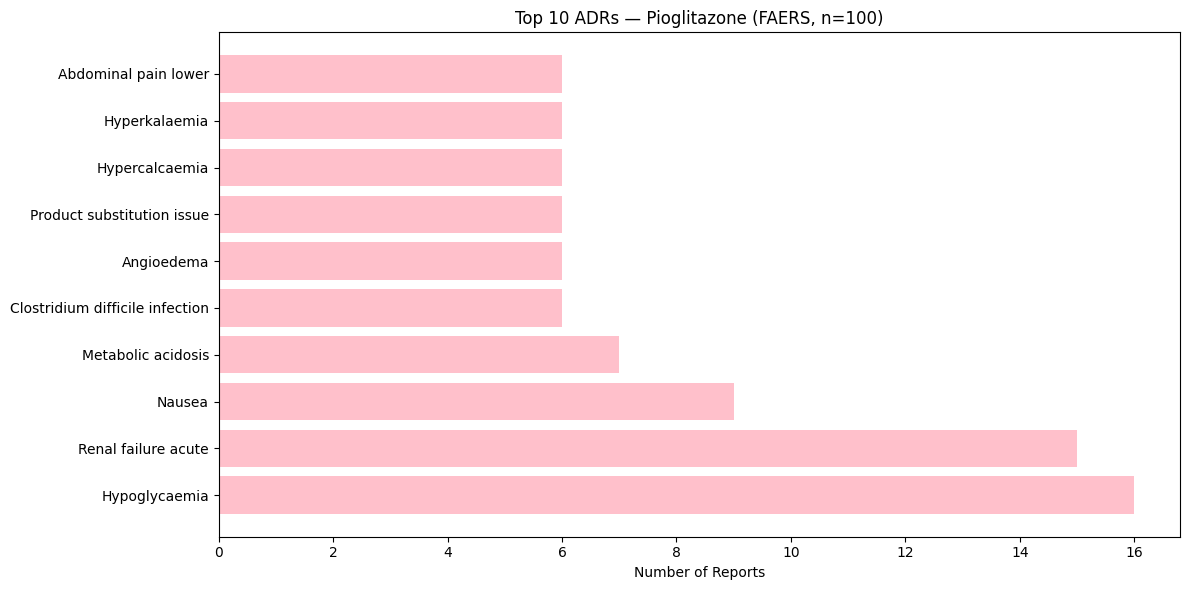

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# get top reactions from your existing df
all_reactions = []
for r in df['reactions']:
    if r:
        for reaction in r.split(', '):
            all_reactions.append(reaction.strip())

top_reactions = Counter(all_reactions).most_common(10)
labels, counts = zip(*top_reactions)

plt.figure(figsize=(12, 6))
plt.barh(labels, counts, color='pink')
plt.xlabel('Number of Reports')
plt.title('Top 10 ADRs — Pioglitazone (FAERS, n=100)')
plt.tight_layout()
plt.savefig('adr_chart.png', dpi=150)
plt.show()

In [ ]:
clean_drug_name(metformin)


NameError: name 'clean_drug_name' is not defined